# Tester_branch에서 최종 모델 성능 확인 진행

In [2]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''
# 데이터 불러오기
wine = load_wine()

# DataFrame으로 변환
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# target 컬럼 추가
df['target'] = wine.target

# feature 데이터 (target 컬럼 제거)
X = df.drop('target', axis=1)

# target 데이터
y = df['target']

# train / test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 확인
print("X_train 크기:", X_train.shape)
print("X_test 크기:", X_test.shape)
print("y_train 크기:", y_train.shape)
print("y_test 크기:", y_test.shape)


# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

X_train 크기: (142, 13)
X_test 크기: (36, 13)
y_train 크기: (142,)
y_test 크기: (36,)


# DT 모델링 성능

Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best accuracy: 0.9444444444444444


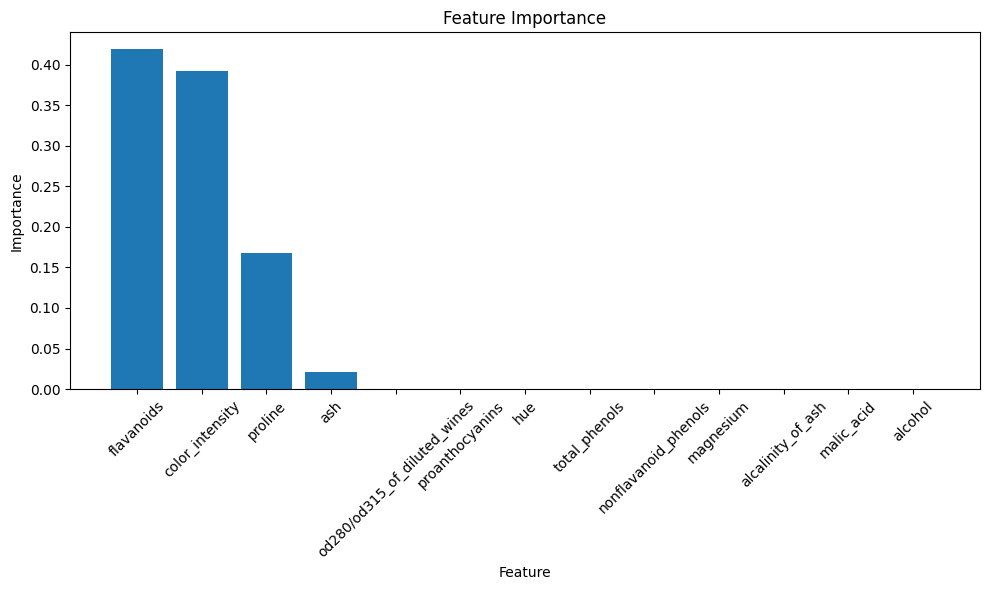

In [3]:
''' 코드를 작성해주세요 '''
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# 모델 생성
dt = DecisionTreeClassifier(random_state=42)

# 하이퍼파라미터 후보 수정
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 5],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearch 설정
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 학습
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 출력
print("Best parameters:", grid_search.best_params_)

# 테스트 데이터 평가
best_model1 = grid_search.best_estimator_
y_pred = best_model1.predict(X_test)

print("Best accuracy:", accuracy_score(y_test, y_pred))

# Feature Importance 시각화
importances = best_model1.feature_importances_
feature_names = X_train.columns

indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])

plt.xticks(range(len(importances)), feature_names[indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.tight_layout()
plt.show()


# XGB 모델링 성능

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best accuracy: 1.0


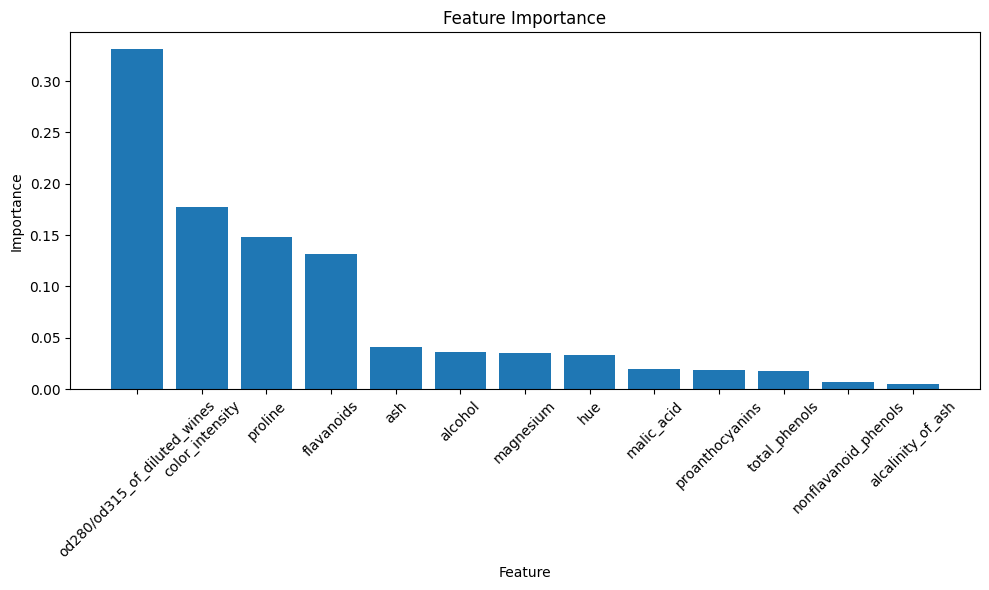

In [4]:
''' 코드를 작성해주세요 '''
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 모델 생성
xgb_model = XGBClassifier(
    objective='multi:softprob',  # 다중분류
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

# GridSearch 설정
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 모델 학습
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 출력
print("Best parameters:", grid_search.best_params_)

# 테스트 데이터 평가
best_model2 = grid_search.best_estimator_
y_pred = best_model2.predict(X_test)

print("Best accuracy:", accuracy_score(y_test, y_pred))



# XGBClassifier 모델에서 Feature Importance 가져오기
importances = best_model2.feature_importances_
feature_names = X_train.columns

# 중요도 내림차순 정렬
indices = importances.argsort()[::-1]

# 시각화
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])

plt.xticks(range(len(importances)), feature_names[indices], rotation=45)  
plt.xlabel("Feature")   
plt.ylabel("Importance") 
plt.title("Feature Importance")

plt.tight_layout()
plt.show()

# 성능 비교 시각화

==============================DT 성능 확인==============================
DT accuracy : 0.94444444444444441977
              precision    recall  f1-score   support

           0     1.0000    0.9286    0.9630        14
           1     0.8750    1.0000    0.9333        14
           2     1.0000    0.8750    0.9333         8

    accuracy                         0.9444        36
   macro avg     0.9583    0.9345    0.9432        36
weighted avg     0.9514    0.9444    0.9449        36

==============================XGB 성능 확인==============================
XGB accuracy : 1.00000000000000000000
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        14
           1     1.0000    1.0000    1.0000        14
           2     1.0000    1.0000    1.0000         8

    accuracy                         1.0000        36
   macro avg     1.0000    1.0000    1.0000        36
weighted avg     1.0000    1.0000    1.0000        36



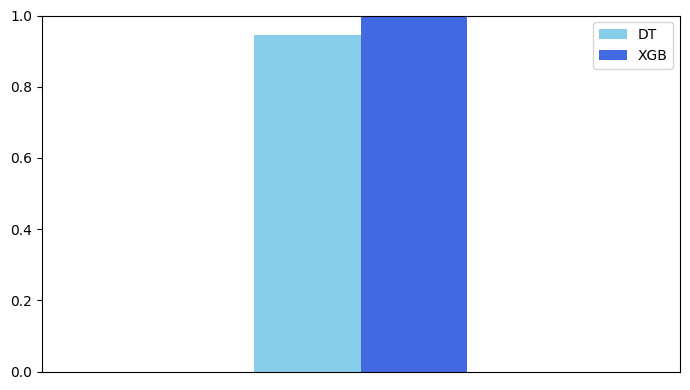

In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import classification_report, accuracy_score

# 1. DT 결과 출력
print("="*30 + "DT 성능 확인" + "="*30)
print(f"DT accuracy : {accuracy_score(y_test, best_model1.predict(X_test)):.20f}")

print(classification_report(y_test, best_model1.predict(X_test), digits=4))


# 2. XGB 결과 출력
print("="*30 + "XGB 성능 확인" + "="*30)
print(f"XGB accuracy : {accuracy_score(y_test, best_model2.predict(X_test)):.20f}")

print(classification_report(y_test, best_model2.predict(X_test), digits=4))



#시각화
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


# 1. 지표 계산
dt_accuracy = accuracy_score(y_test, best_model1.predict(X_test))
xgb_accuracy = accuracy_score(y_test, best_model2.predict(X_test))


# 2. 그래프 설정
plt.figure(figsize=(7, 4))

bar_width = 0.2

bar1 = plt.bar(-bar_width, dt_accuracy, width=bar_width, color='skyblue', label='DT', align='edge')
bar2 = plt.bar(0, xgb_accuracy, width=bar_width, color='royalblue', label='XGB', align='edge')

plt.ylim(0, 1.0) 
plt.xticks([])
plt.xlim(-bar_width * 3, bar_width * 3) 
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()